# Reproduccion análisis desinformacion

Este notebook tiene como objetivo principal la **validación y auditoría** de los resultados sustantivos del trabajo de grado. Para garantizar una experiencia de usuario fluida y permitir la verificación inmediata de las métricas de Machine Learning, este proceso comienza a partir del dataset consolidado.

### 1. Etapa de recolección (API de Meta Graph)
La obtención original de los registros publicitarios se realizó mediante la **API de Meta Ad Library**. La replicación exacta de esta fase presenta barreras de acceso externas: requiere una cuenta de desarrollador verificada por Meta y un *Access Token* vigente suministrado por API Graph.
Cada registro en el dataset adjunto cuenta con un `id` único y público. Cualquier evaluador puede verificar la existencia y el contenido original de la pauta consultando dicho ID directamente en la [Librería de Anuncios de Meta](https://www.facebook.com/ads/library/).

### 2. Preparación de infraestructura (Scraping y transcripción)
Antes del análisis, se ejecutó un flujo de extracción de datos que incluye
* **Web scraping automatizado:** Uso de **[Selenium](https://pypi.org/project/selenium/)** para la descarga del contenido publicitario (imágenes y videos).
* **Visión artificial y audio-a-Texto:** Implementación de OCR (**[PyOCR](https://pypi.org/project/pyocr/))** para lectura de imágenes y **[Whisper](https://github.com/openai/whisper)** para la transcripción de piezas audiovisuales.

**Nota sobre reproducibilidad:**  Replicar estas tareas implicaría una gran carga técnica en materia de capacidad y configuración

### 3. Sistema de etiquetado débil (Weak supervision)
En esta reproducción, trabajaremos con las transcripciones ya obtenidas, las cuales pasan por un proceso de detección multietiqueta para identificar señales de "engañosidad estilística":

* **Detección de groserías y odio:** Implementado mediante [spanlp](https://github.com/jfreddypuentes/spanlp) y [modelos especializados en detección de discurso de odio](https://github.com/esaidh266/Algorithm-for-detection-of-hate-speech-in-Spanish/tree/main) en español.
* **Análisis afectivo:** Uso de la librería [pysentimiento](https://github.com/pysentimiento/pysentimiento?tab=readme-ov-file) para la identificacion de sentimientos y emociones predominantes.
* **Menciones:** Identificación de menciones a figuras políticas.

---

### Conclusión del alcance
La lógica completa de obtención de datos, funciones de la API y scripts de transcripción se encuentran debidamente documentados y disponibles en los **Notebooks 1, 2 y 3** de este repositorio para fines de auditoría de código.

Sin embargo, para efectos de esta **validación de resultados finales**, se iniciará desde el dataset ya transcrito y normalizado. Esto permite que el evaluador pueda ejecutar el modelo de Machine Learning y generar las explicaciones SHAP de manera inmediata, eficiente y transparente.


El contenido final del repositorio contiene el apartado de graficas, el cual no es relevante para esta reproduccion y se puede consultar en el **Notebook 5**.

## Preparacion del Entorno

In [ ]:
!pip install shap

### Librerias

In [ ]:
import numpy as np
import pandas as pd
# Modelos
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
# ML Herrramientas
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# Metricas
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
# Graficas
import shap
import seaborn as sns
import matplotlib.pyplot as plt

## Data Set y Diccionario de Datos

In [ ]:
# Carga del data set

# Ruta de git_hub
content_path = 'https://github.com/camilamarin96/desinformacion-meta-medellin2023/raw/main/Dataset/Aleatorizacion-DataSetCompleto%20(1)%20(1)-2.xlsx'

#cargar df
df_clasificado = pd.read_excel(content_path)
print(df_clasificado.sample(4))

      categoría            id              page_name  \
1312          3  8.332688e+14         Fico Gutiérrez   
189           2  3.052070e+14   Recuperemos Medellín   
851           3  1.490000e+15        Albert Corredor   
1413          3  8.786426e+14  Juan David Valderrama   

                                   transcripcion_pg_ext  \
1312  Aquí seguimos, aquí dándole duro. Seguimos com...   
189   ['Medellín se volvió muy insegura y debemos re...   
851   Nuestras mujeres tienen un rol fundamental en ...   
1413  Acá vemos como en muchos territorios aplican a...   

                                            trans_clean  \
1312  aqui seguimos aqui dandole duro seguimos comun...   
189        medellin volvio insegura debemos recuperarla   
851   mujeres rol fundamental estructura funcionamie...   
1413  aca vemos territorios aplican abortas urbanas ...   

                                             token_text  Hate Speech  \
1312  ['aqui', 'seguimos', 'aqui', 'dandole', 'duro'...

### Diccionario de Datos
**Metadatos de la Publicación**

- **id**: Identificador único del post.

- **page_name**: Nombre de la figura pública o cuenta que emite el mensaje.

**Procesamiento de Texto (NLP)**
- **transcripcion_pq_ext**: Transcripción del texto generada a partir de Whisper-OCR.

- **trans_clean**: Versión del texto tras limpieza (remoción de símbolos y normalización).

- **token_text**: El texto segmentado en palabras individuales o "tokens".

**Análisis de Sentimiento, Emoción y Etiquetas de Contenido**

- **Hate Speech**: Indicador binario (0 o 1) de discurso de odio.

- **prob_emoción**: Puntaje de confianza del modelo sobre la emoción detectada.

- **emocion**: Etiqueta de la emoción identificada (ej. *anger*, *others*).

- **prob_sentimient**: Puntaje de confianza sobre la polaridad del texto (positiva, negativa o neutra)

- **Groserias**: Indicador binario (0 o 1) de presencia de lenguaje soez.

- **menciones_binaria**: Indicador binario (0 a 1) sobre menciones a candidatos o figuras relevantes

---

**Bloque de Validación**
- **prob_sentimient**: Probabilidad de sentimiento, resultado final. 1 si *prob_sentimient* es >0.5; 0 en caso contrario.

- **prob_emoción**: Probabilidad de emoción, resultado final: 1 si *prob_emoción* es >0; 0 en caso contrario .

- **Hate Speech**: Discurso de odio (segunda etiqueta).

- **Groserias**: Groserías (segunda etiqueta).

- **menciones_bina**: Menciones (segunda etiqueta).

- **Prob_Fake**: Probabilidad de que el contenido sea desinformación. Si la suma de (Sentimiento + Emoción + Hate Speech + Groserías + Menciones) es ≥3, se marca como 1 (Fake).

### Exploracion de los datos

In [ ]:
# tamaño
df_clasificado.shape

(3732, 18)

In [ ]:
# tipo de datos
df_clasificado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   categoría             3732 non-null   int64  
 1   id                    3732 non-null   float64
 2   page_name             3732 non-null   object 
 3   transcripcion_pg_ext  3732 non-null   object 
 4   trans_clean           3722 non-null   object 
 5   token_text            3732 non-null   object 
 6   Hate Speech           3732 non-null   int64  
 7   prob_emoción          3732 non-null   float64
 8   emocion               3732 non-null   object 
 9   prob_sentimiento      3732 non-null   float64
 10  Groserias             3732 non-null   int64  
 11  menciones_binaria     3732 non-null   int64  
 12  prob_sentimiento.1    3732 non-null   int64  
 13  prob_emoción.1        3732 non-null   int64  
 14  Hate Speech.1         3732 non-null   int64  
 15  Groserias.1          

In [ ]:
# Estadistica Descriptiva
df_clasificado.describe()

,categoría,id,Hate Speech,prob_emoción,prob_sentimiento,Groserias,menciones_binaria,prob_sentimiento.1,prob_emoción.1,Hate Speech.1,Groserias.1,menciones_binaria.1,Prob_Fake
count,3732.000000,3.732000e+03,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000
mean,3.372186,1.197043e+15,0.131565,0.178249,0.092577,0.034834,0.113612,0.116292,0.990622,0.131565,0.034834,0.113612,0.092444
std,0.724801,1.407202e+15,0.338062,0.282449,0.253362,0.183383,0.317382,0.320617,0.096400,0.338062,0.183383,0.317382,0.289690
min,1.000000,1.090547e+14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.429954e+14,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,8.445497e+14,0.000000,0.047500,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,1.340000e+15,0.000000,0.130250,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,2.420000e+16,1.000000,0.983000,0.994000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Limpieza del Dataframe


In [ ]:
df_copy = df_clasificado.copy()

In [ ]:
# Eliminar columnas que no necesitamos
df_copy.drop(columns=[
    'id',
    'page_name',
    'transcripcion_pg_ext',
    'token_text',
    'Hate Speech',
    'prob_sentimiento',
    'emocion',
    'prob_emoción',
    'Groserias',
    'menciones_binaria',
    'prob_sentimiento.1',
    'prob_emoción.1',
    'Hate Speech.1',
    'Groserias.1',
    'menciones_binaria.1'
], inplace=True)

In [ ]:
df_copy.sample(4)

,categoría,trans_clean,Prob_Fake
1344,3,aqui seguimos aqui dandole duro seguimos comun...,0
456,3,valde alcalde gente importante tecnologia arte...,0
640,3,explotacion sexual fenomeno combatir toda cont...,0
3627,4,¡si puede nnfelipealcaldenhayquehacerloquehayq...,0


In [ ]:
# verificar datos nullos
df_copy.isnull().sum()

,0
categoría,0
trans_clean,10
Prob_Fake,0


In [ ]:
#Eliminar datos nulos
df_copy.dropna(inplace=True)

In [ ]:
# tamaño del dataset luego de la limpieza de datos nulos o vacios
df_copy.shape

(3722, 3)

## Modelos

Se evalúan tres algoritmos de clasificación. Los tres modelos son: Random Forest, un conjunto de árboles de decisión que promedia predicciones sobre submuestras aleatorias del corpus; XGBoost (Gradient Boosting), que entrena árboles de forma secuencial corrigiendo los errores del anterior; y Regresión Logística, que estima directamente la probabilidad de desinformación asignando un coeficiente interpretable a cada término. Los tres se entrenan con el 80% de los datos y se evalúan sobre el 20% restante. La sección siguiente reporta exactitud (accuracy), matriz de confusión y AUC-ROC para cada uno.
...



### Preparacion y division de la data

In [ ]:
#Asignación variables
X = df_copy['trans_clean']
y = df_copy['Prob_Fake']

# Dividir data de testeo y entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state=42)

# Se importa y se instancia el vectorizador CountVectorizer (modelo Bag of Words)
vect = CountVectorizer()

# Se ajusta el vectorizador al texto de entrenamiento y se transforma en una matriz de términos
X_train_dtm = vect.fit_transform(X_train)

# Se transforma el texto de prueba utilizando el mismo vocabulario aprendido del entrenamiento
X_test_dtm = vect.transform(X_test)

# Se imprime la forma (número de documentos, número de palabras) de las matrices resultantes
print(X_train_dtm.shape, X_test_dtm.shape)

(2977, 7906) (745, 7906)


### Random Forest

In [ ]:
# Crea una instancia del modelo Random Forest con una semilla fija para reproducibilidad
model_1 = RandomForestClassifier(random_state=42)

# Entrena el modelo usando la matriz de términos del conjunto de entrenamiento y sus etiquetas
# (en lugar de texto original, se usan las representaciones numéricas obtenidas con CountVectorizer)
model_1.fit(X_train_dtm, y_train)

# Realiza predicciones sobre el conjunto de prueba utilizando también su representación numérica
y_pred = model_1.predict(X_test_dtm)


In [ ]:
# Calcula la precisión del modelo comparando predicciones con las etiquetas reales
accuracy = accuracy_score(y_test, y_pred)

# Imprime la precisión en porcentaje con dos decimales
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 97.99%


In [ ]:
# Mostrar métricas de evaluación
print(classification_report(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       678
           1       0.98      0.79      0.88        67

    accuracy                           0.98       745
   macro avg       0.98      0.89      0.93       745
weighted avg       0.98      0.98      0.98       745

F1-Score: 0.8760330578512396


### GBOOST

In [ ]:
#Implementación modelo
model_3 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model_3.fit(X_train_dtm, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:53:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Genera las predicciones del modelo 3 en el conjunto de prueba (X_test_dtm)
y_pred_3 = model_3.predict(X_test_dtm)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_3))

Accuracy: 0.9798657718120806


In [ ]:
#Métricas de evaluación
print("Classification Report:\n", classification_report(y_test, y_pred_3))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       678
           1       0.96      0.81      0.88        67

    accuracy                           0.98       745
   macro avg       0.97      0.90      0.93       745
weighted avg       0.98      0.98      0.98       745



### Regresión Logística

En esta sección se presenta la implementación del modelo de Regresión Logística, el cual obtuvo la mayor exactitud (98%) entre los tres algoritmos evaluados. A diferencia de Random Forest y XGBoost, que operan como modelos de caja negra, la Regresión Logística asigna un coeficiente interpretable a cada término del vocabulario, lo que permite identificar directamente qué palabras aumentan o reducen la probabilidad de que un anuncio sea clasificado como desinformación. Esta propiedad la convierte en el modelo más adecuado para los objetivos analíticos de este estudio. A continuación se visualizan la matriz de confusión y el reporte de clasificación con precisión, recall y F1-score.


In [ ]:
# Regresión logística
model_2 = LogisticRegression(random_state=42)

# Entrena el modelo usando la matriz de términos del conjunto de entrenamiento y sus etiquetas
model_2.fit(X_train_dtm, y_train)

LogisticRegression(random_state=42)

In [ ]:
# Genera las predicciones del modelo en el conjunto de prueba
y_pred_2 = model_2.predict(X_test_dtm)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_2))

Accuracy: 0.9812080536912752


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred_2))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       678
           1       0.98      0.81      0.89        67

    accuracy                           0.98       745
   macro avg       0.98      0.90      0.94       745
weighted avg       0.98      0.98      0.98       745



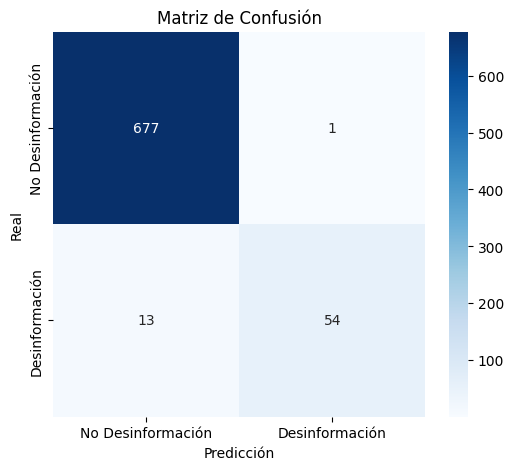

In [ ]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred_2)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Desinformación', 'Desinformación'], yticklabels=['No Desinformación', 'Desinformación'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.savefig("matriz_confusion.png", dpi=300, bbox_inches="tight")

plt.show()

#### Grafica SHAP
Muestra las palabras más influyentes en las predicciones, su frecuencia y su impacto (positivo o negativo) en la salida del modelo



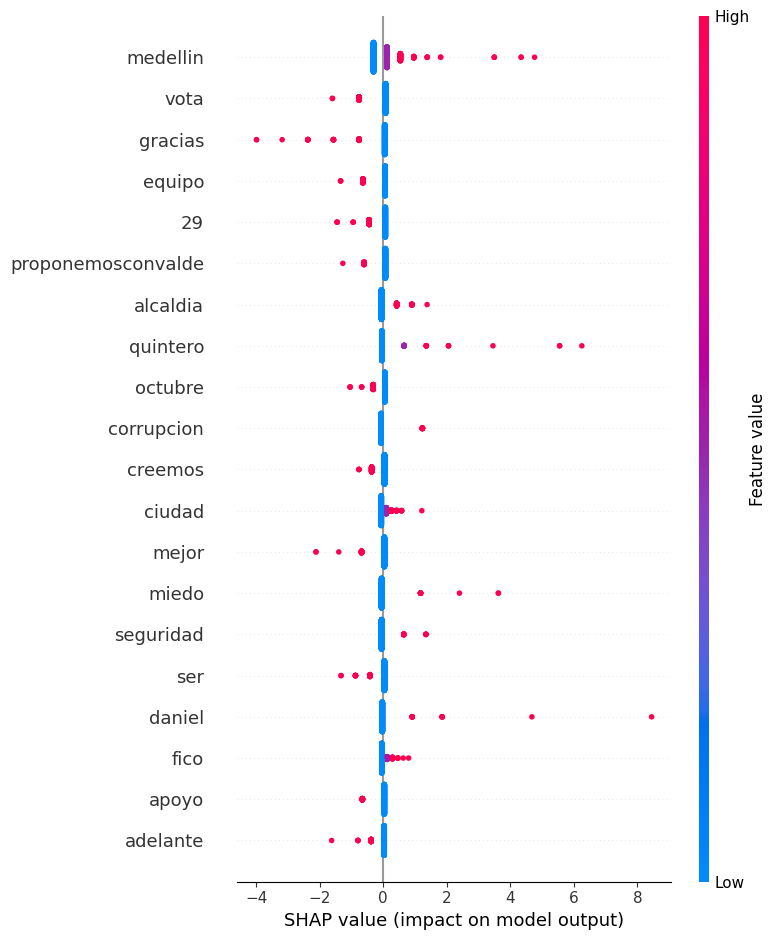

In [ ]:
# Obtener los nombres de las palabras
feature_names = vect.get_feature_names_out()

# Convertir las matrices sparse a DataFrames con nombres de columnas
X_train_df = pd.DataFrame(X_train_dtm.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_dtm.toarray(), columns=feature_names)

# Crear el explainer usando el modelo y el DataFrame de entrenamiento
explainer = shap.Explainer(model_2, X_train_df)

# Calcular valores SHAP sobre el set de prueba
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

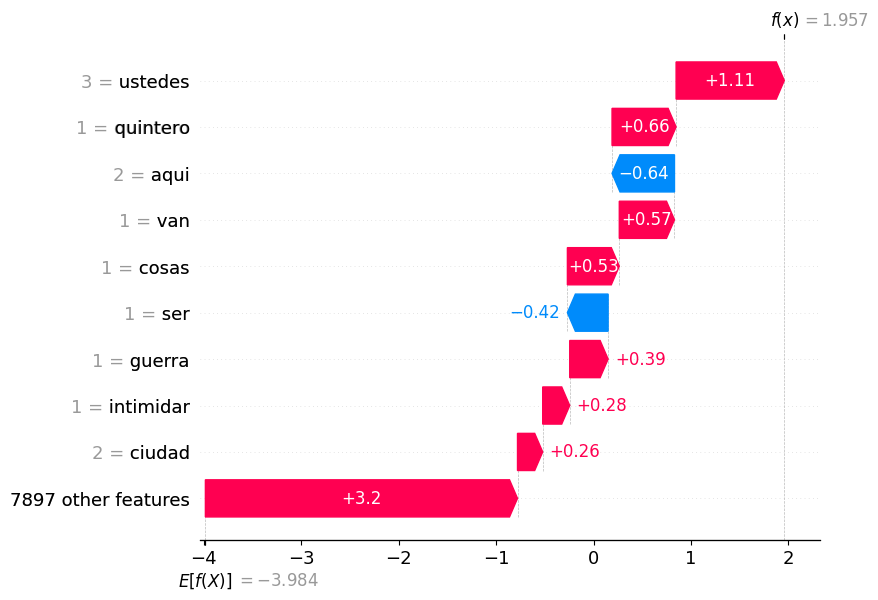

In [ ]:
# Por ejemplo, para el primer documento del test set
shap.plots.waterfall(shap_values[0])

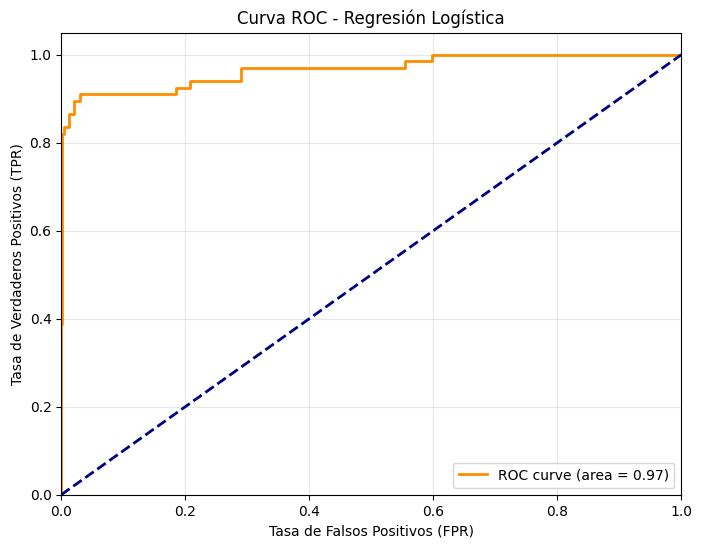

AUC Score: 0.9662


In [ ]:
# Obtener las probabilidades de la clase positiva (1)
y_probs_2 = model_2.predict_proba(X_test_dtm)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_2)

# Calcular el AUC (Área bajo la curva)
auc_score = roc_auc_score(y_test, y_probs_2)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'AUC Score: {auc_score:.4f}')

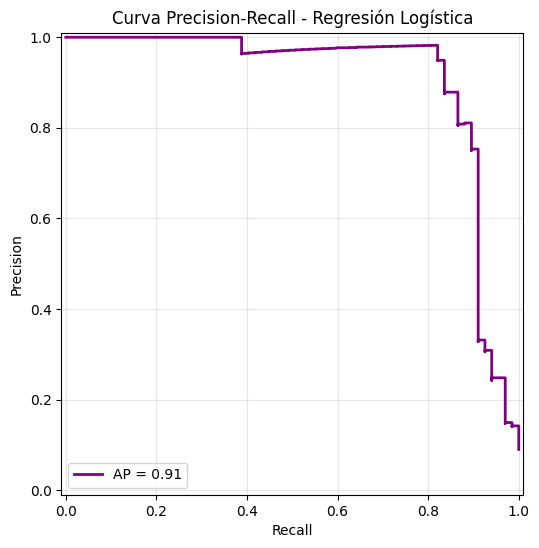

Average Precision (AP): 0.9073


In [ ]:
# Calcular precision y recall
precision, recall, _ = precision_recall_curve(y_test, y_probs_2)
average_precision = average_precision_score(y_test, y_probs_2)

# Graficar
plt.figure(figsize=(8, 6))
disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=average_precision)
disp.plot(ax=plt.gca(), color='purple', lw=2)
plt.title('Curva Precision-Recall - Regresión Logística')
plt.grid(alpha=0.3)
plt.show()

print(f'Average Precision (AP): {average_precision:.4f}')

Mejor Umbral (Best Threshold): 0.4070
Mejor F1-Score: 0.8943


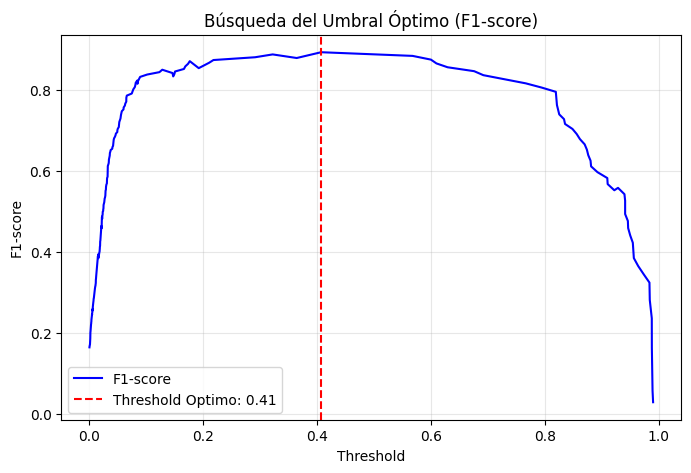

In [ ]:
# Calcular precision, recall y thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_2)

# Calcular F1-score para cada umbral
# Evitamos división por cero sumando un epsilon
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Encontrar el índice del F1-score máximo (excluyendo el último valor de precision/recall que no tiene threshold)
ix = np.argmax(f1_scores[:-1])
best_threshold = thresholds[ix]
best_f1 = f1_scores[ix]

print(f'Mejor Umbral (Best Threshold): {best_threshold:.4f}')
print(f'Mejor F1-Score: {best_f1:.4f}')

# Graficar F1-score vs Threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1-score', color='blue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Threshold Optimo: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('Búsqueda del Umbral Óptimo (F1-score)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()